# Reliability — Consistency (C) metrics

Session-level port of the hal-harness `reliability_eval` **Consistency** metrics to this
output-consistency **replay** experiment (same recorded trace replayed *K=10* times against a
live server). All formulas live in `compare/reliability.py`; this notebook only loads and
visualizes them.

**Unit of analysis.** hal-harness runs an agent *task* K times; here the analog of a task is a
**session** (one recorded trace), and its K "runs" are the K replays. Per session we compute the
metrics across its 10 replays, then compare **across sessions** (Part 1) and **across models** (Part 2).

| Metric | Meaning (1 = perfectly consistent) |
|---|---|
| **C_out** | Outcome consistency — variance of a binary per-run success flag, normalized by `p(1-p)`. *Success is a proxy:* every event `ok` and no `length`-truncation. |
| **C_traj_d** | Trajectory *distribution* — `1 − mean pairwise JSD` of tool-call histograms (successful runs). |
| **C_traj_s** | Trajectory *sequence* — mean pairwise normalized-Levenshtein similarity of tool-call order (successful runs). |
| **C_res** | Resource consistency — `exp(−mean CV)` over cost / time / api_calls / actions / errors / latency. |
| **C_conf** | Confidence consistency — **N/A**: replay carries no model self-reported confidence. |
| **R_con** | Equal-weight aggregate of C_out, mean(C_traj_d, C_traj_s), C_res. |

> **Caveats.** (1) In replay every event is fed the *original recorded input*, so a session
> "trajectory" is a bundle of independent per-event outputs, not a causally chained agent path —
> C_traj measures "same fixed input → same tool structure". (2) With the truncation-based success
> proxy, C_traj is only defined for sessions with ≥2 clean runs, so it can be sparse (esp. for the
> reasoning/`thinking` model, which truncates often). (3) C_out mostly reflects *truncation*
> consistency under this proxy — edit `session_success` in the library to change it.

In [1]:
import sys, math
from pathlib import Path
from dataclasses import asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook lives in experiments/consistency-replay; walk up to find the kit + repo root.
KIT = Path.cwd()
while not (KIT / "compare" / "reliability.py").exists() and KIT != KIT.parent:
    KIT = KIT.parent
sys.path.insert(0, str(KIT))
from compare import compute_consistency  # noqa: E402

REPORTS = KIT.parent.parent / "reports-consistency" / "tau2_airline"

# The three models under comparison (base dir = the run_1..run_10 parent).
MODELS = {
    "instruct": REPORTS / "qwen-qwen3-vl-235b-a22b-instruct" / "20260804-144419",
    "fp8-a100": REPORTS / "qwen-qwen3-5-397b-a17b-fp8-a100" / "20260804-154811",
    "thinking": REPORTS / "qwen-qwen3-vl-235b-a22b-thinking" / "20260804-153833",
}

METRICS = ["c_out", "c_traj_d", "c_traj_s", "c_res", "r_con"]  # c_conf omitted (always NaN)
LABELS = {"c_out": "C_out", "c_traj_d": "C_traj_d", "c_traj_s": "C_traj_s",
          "c_res": "C_res", "r_con": "R_con"}

# Okabe–Ito colorblind-safe palette.
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})


def sessions_df(base) -> pd.DataFrame:
    "Per-session metrics for one model as a DataFrame."
    session_metrics, _summary, _skipped = compute_consistency(str(base))
    return pd.DataFrame([asdict(m) for m in session_metrics])


def summary_of(base) -> dict:
    "Library's mean±SE aggregate {metric: {mean, se, n}} for one model."
    _sm, summary, _sk = compute_consistency(str(base))
    return summary

## Part 1 — Single model: consistency across sessions

Compare how consistent the *same model* is from session to session. Change `SINGLE` to inspect
another model.

In [2]:
SINGLE = "instruct"
df1 = sessions_df(MODELS[SINGLE])
df1.set_index("session_id")[["n_runs", "n_success"] + METRICS].rename(columns=LABELS)

,n_runs,n_success,C_out,C_traj_d,C_traj_s,C_res,R_con
session_id,,,,,,,
trace0_d5c4f35bed6a_f98e121b,10,0,1.0,NaN,NaN,0.857026,0.928513
trace1_45eff42acfad_60e35976,10,10,1.0,0.992582,0.937173,0.962287,0.975722
trace2_45eff42acfad_5cf9a685,10,9,0.0,1.000000,1.000000,0.845829,0.615276
trace3_d3d3e0d1a8f8_20b42b16,10,0,1.0,NaN,NaN,0.960866,0.980433
trace4_247b0c0650d3_f6b29499,10,0,1.0,NaN,NaN,0.871933,0.935966
trace5_45eff42acfad_3db0b212,10,10,1.0,0.974168,0.944790,0.925331,0.961603
trace6_e416e0e39ffd_821cbb21,10,0,1.0,NaN,NaN,0.898764,0.949382
trace7_266b7f5a8aa9_0ff1eac5,10,0,1.0,NaN,NaN,0.719215,0.859608
trace8_ab2f8ca80599_e217deba,10,0,1.0,NaN,NaN,0.951666,0.975833


### Descriptive statistics (across sessions)

In [3]:
desc = df1[METRICS].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
desc.rename(index=LABELS).round(3)

,count,mean,std,min,25%,50%,75%,max
C_out,10.0,0.900,0.316,0.000,1.000,1.000,1.000,1.000
C_traj_d,3.0,0.989,0.013,0.974,0.983,0.993,0.996,1.000
C_traj_s,3.0,0.961,0.034,0.937,0.941,0.945,0.972,1.000
C_res,10.0,0.880,0.078,0.719,0.849,0.885,0.945,0.962
R_con,10.0,0.908,0.110,0.615,0.908,0.943,0.972,0.980


### Per-session values (heatmap)

Each row is a session; a `—` means the metric was undefined (e.g. C_traj with <2 clean runs).

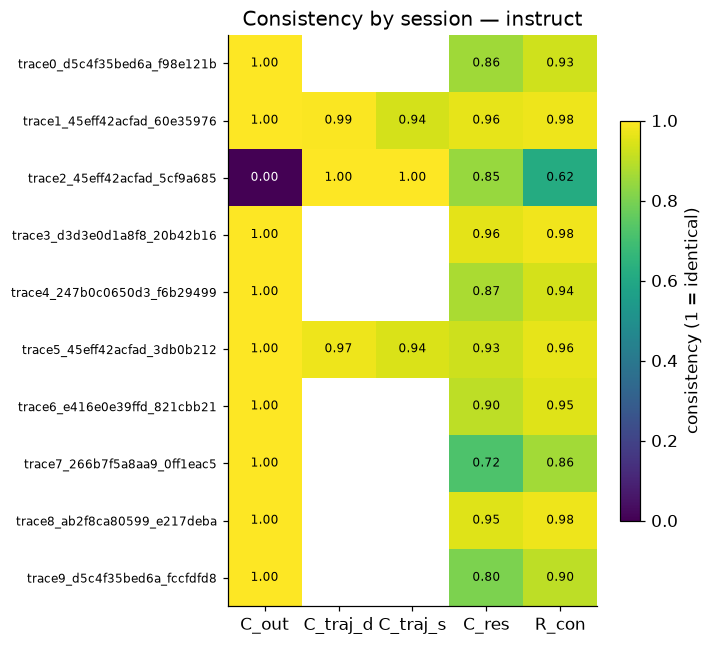

In [4]:
mat = df1.set_index("session_id")[METRICS].rename(columns=LABELS)
fig, ax = plt.subplots(figsize=(6.5, 0.45 * len(mat) + 1.5))
im = ax.imshow(np.ma.masked_invalid(mat.values), aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns)
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=8)
ax.grid(False)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        txt = "—" if (v is None or (isinstance(v, float) and np.isnan(v))) else f"{v:.2f}"
        col = "white" if (isinstance(v, float) and np.isnan(v)) or v < 0.6 else "black"
        ax.text(j, i, txt, ha="center", va="center", color=col, fontsize=8)
ax.set_title(f"Consistency by session — {SINGLE}")
fig.colorbar(im, ax=ax, shrink=0.7, label="consistency (1 = identical)")
plt.tight_layout(); plt.show()

### Distribution across sessions

Box = IQR, line = median; points are individual sessions.

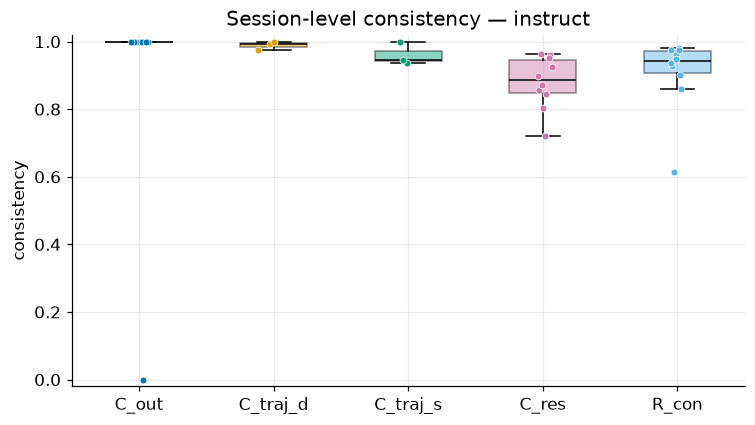

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
data = [df1[m].dropna().values for m in METRICS]
bp = ax.boxplot(data, tick_labels=[LABELS[m] for m in METRICS], showfliers=False,
                patch_artist=True, medianprops=dict(color="black"))
for patch, c in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(c); patch.set_alpha(0.45)
rng = np.random.default_rng(0)
for i, m in enumerate(METRICS, 1):
    y = df1[m].dropna().values
    ax.scatter(rng.normal(i, 0.05, len(y)), y, s=20, color=PALETTE[i - 1],
               edgecolor="white", linewidth=0.5, zorder=3)
ax.set_ylim(-0.02, 1.02); ax.set_ylabel("consistency")
ax.set_title(f"Session-level consistency — {SINGLE}")
plt.tight_layout(); plt.show()

### Which sessions are least consistent overall (R_con)?

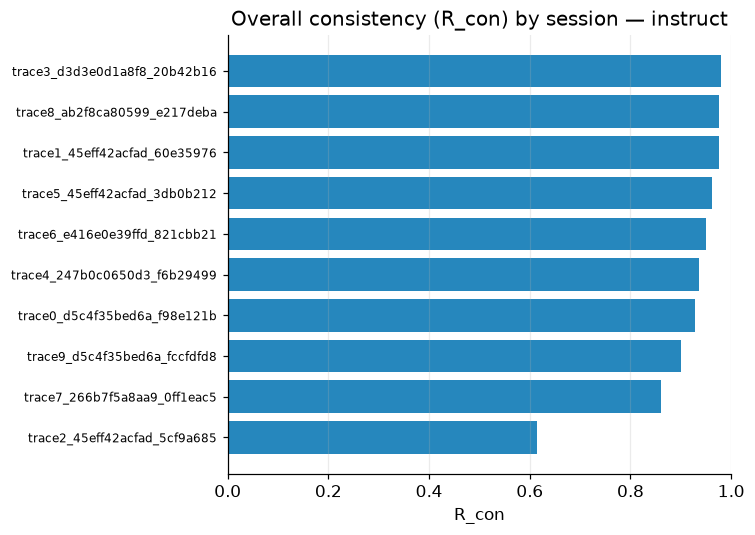

In [6]:
s = df1.set_index("session_id")["r_con"].sort_values()
fig, ax = plt.subplots(figsize=(7, 0.4 * len(s) + 1))
ax.barh(range(len(s)), s.values, color=PALETTE[0], alpha=0.85)
ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8)
ax.set_xlim(0, 1); ax.set_xlabel("R_con"); ax.grid(axis="y", alpha=0)
ax.set_title(f"Overall consistency (R_con) by session — {SINGLE}")
plt.tight_layout(); plt.show()

## Part 2 — Cross-model comparison

Compare the three models on the same tau2-airline traces. Lower values mean the model's repeated
executions diverge more.

In [7]:
frames = []
for label, base in MODELS.items():
    d = sessions_df(base); d.insert(0, "model", label); frames.append(d)
alldf = pd.concat(frames, ignore_index=True)
print("sessions per model:", alldf.groupby("model").size().to_dict())
alldf.head()

sessions per model: {'fp8-a100': 10, 'instruct': 10, 'thinking': 10}


,model,session_id,n_runs,n_success,c_out,c_traj_d,c_traj_s,c_conf,c_res,r_con
0,instruct,trace0_d5c4f35bed6a_f98e121b,10,0,1.0,NaN,NaN,NaN,0.857026,0.928513
1,instruct,trace1_45eff42acfad_60e35976,10,10,1.0,0.992582,0.937173,NaN,0.962287,0.975722
2,instruct,trace2_45eff42acfad_5cf9a685,10,9,0.0,1.000000,1.000000,NaN,0.845829,0.615276
3,instruct,trace3_d3d3e0d1a8f8_20b42b16,10,0,1.0,NaN,NaN,NaN,0.960866,0.980433
4,instruct,trace4_247b0c0650d3_f6b29499,10,0,1.0,NaN,NaN,NaN,0.871933,0.935966


### Aggregate consistency per model (mean across sessions)

In [8]:
models = list(MODELS)
means = pd.DataFrame(
    {LABELS[m]: {mdl: summary_of(MODELS[mdl])[m]["mean"] for mdl in models} for m in METRICS}
)
means.round(3)

,C_out,C_traj_d,C_traj_s,C_res,R_con
instruct,0.9,0.989,0.961,0.880,0.908
fp8-a100,0.8,0.984,0.918,0.818,0.810
thinking,0.9,NaN,NaN,0.462,0.681


### Mean ± SE by metric and model

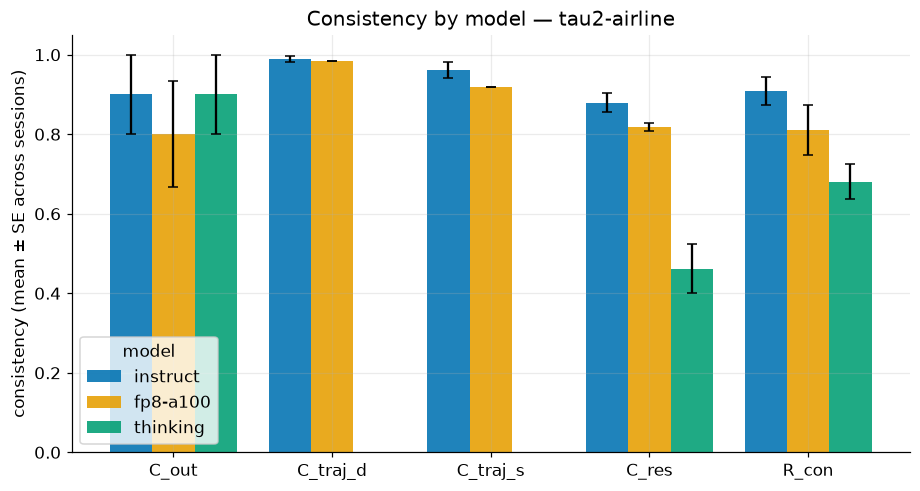

In [9]:
x = np.arange(len(METRICS)); w = 0.8 / len(models)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
for k, mdl in enumerate(models):
    summ = summary_of(MODELS[mdl])
    mu = [summ[m]["mean"] if summ[m]["mean"] is not None else np.nan for m in METRICS]
    se = [summ[m]["se"] if summ[m]["se"] is not None else 0 for m in METRICS]
    ax.bar(x + k * w, mu, w, yerr=se, capsize=3, label=mdl, color=PALETTE[k], alpha=0.88)
ax.set_xticks(x + w * (len(models) - 1) / 2)
ax.set_xticklabels([LABELS[m] for m in METRICS])
ax.set_ylim(0, 1.05); ax.set_ylabel("consistency (mean ± SE across sessions)")
ax.set_title("Consistency by model — tau2-airline"); ax.legend(title="model")
plt.tight_layout(); plt.show()

### Session-level distribution by model

How the per-session values spread within each model (overall R_con and resource C_res).

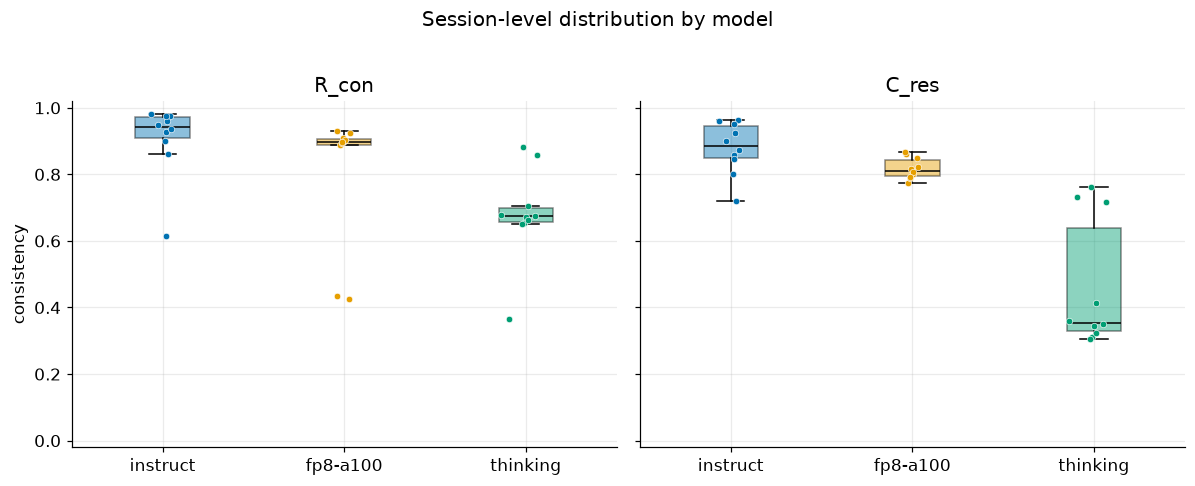

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, metric in zip(axes, ["r_con", "c_res"]):
    data = [alldf[alldf.model == mdl][metric].dropna().values for mdl in models]
    bp = ax.boxplot(data, tick_labels=models, showfliers=False, patch_artist=True,
                    medianprops=dict(color="black"))
    for patch, c in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(c); patch.set_alpha(0.45)
    rng = np.random.default_rng(1)
    for i, mdl in enumerate(models, 1):
        y = alldf[alldf.model == mdl][metric].dropna().values
        ax.scatter(rng.normal(i, 0.05, len(y)), y, s=18, color=PALETTE[i - 1],
                   edgecolor="white", linewidth=0.4, zorder=3)
    ax.set_title(LABELS[metric]); ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("consistency")
fig.suptitle("Session-level distribution by model", y=1.02)
plt.tight_layout(); plt.show()

### Takeaways

Read the bars/boxes together with the coverage counts (`n`) — a high C_traj on a model that only had
a couple of clean sessions is thin evidence. Points to check when interpreting:

- **C_res** is the most comparable metric across models (defined for every session, no success gate).
- **C_traj_d / C_traj_s** coverage depends on how many sessions completed cleanly under the success
  proxy; the `thinking` model may have few or none.
- **C_conf** is intentionally absent (no confidence signal in tau2 replay data).

To change the outcome definition (and thus C_out and C_traj coverage), edit `session_success` in
`compare/reliability.py` — every caller, including this notebook, picks up the change.